In [4]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import re
import emoji
import nltk
import random
import matplotlib.pyplot as plt
import seaborn as sns
import string
import tensorflow as tf
import os
import pickle
import scipy

from emoji import demojize
from wordcloud import WordCloud
from collections import Counter
from imblearn.over_sampling import SMOTE

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE  # For visualizing class separability
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from textblob import TextBlob  # For spelling correction
import contractions  # For expanding contractions (e.g., "don't" -> "do not")
from gensim.models import Word2Vec
# import gensim
# from scipy.linalg import triu

import warnings
warnings.filterwarnings("ignore")


In [5]:
# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [6]:
corpus_df = pd.read_csv("./Sentiment_Data.csv", encoding="ISO-8859-1")

In [7]:
corpus_df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [8]:
# Check unique sentiments
corpus_df['Sentiment'].unique()

array(['Mild_Pos', 'Strong_Pos', 'Neutral', 'Strong_Neg', 'Mild_Neg'],
      dtype=object)

In [9]:
# Check the info of the dataframe
corpus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB


In [10]:
# Check the tweets associated with each sentiment
corpus_df.groupby('Sentiment').count()

,Tweet
Sentiment,
Mild_Neg,34056
Mild_Pos,64004
Neutral,77015
Strong_Neg,42556
Strong_Pos,233700


## 1a. Text Cleaning

In [11]:
# Slang Dictionary
slang_dict = {
    "omg": "oh my god",
    "lol": "laugh out loud",
    "btw": "by the way",
    "idk": "i do not know",
    "smh": "shaking my head",
    "afaik": "as far as i know",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "icymi": "in case you missed it",
    "fwiw": "for what it is worth",
    "ftw": "for the win",
    "lmk": "let me know",
    "rn": "right now",
    "thx": "thanks",
    "til": "today i learned",
    "brb": "be right back",
    "gg": "good game",
    "noob": "newbie",
    "ootd": "outfit of the day",
    "fyp": "for you page",
    "hmu": "hit me up",
    "iiuc": "if i understand correctly",
    "ikr": "i know, right",
    "irl": "in real life",
    "iss": "i am so sorry",
    "jsyk": "just so you know",
    "lowkey": "quietly",
    "highkey": "obviously",
    "ngl": "not gonna lie",
    "oot": "out of the",
    "pls": "please",
    "rizz": "charisma",
    "ship": "support a romantic relationship",
    "slay": "do something well",
    "s/o": "shoutout",
    "stan": "support",
    "tbf": "to be fair",
    "tea": "gossip",
    "vibe check": "evaluation of mood",
    "wtf": "what the freak",
    "wym": "what you mean",
    "yaaas": "strong agreement",
    "cc": "carbon-copy",
    "cx": "correction",
    "ct": "cut tweet",
    "dm": "direct message",
    "ht": "hat tip",
    "mt": "modified tweet",
    "prt": "please retweet",
    "rt": "retweet",
    "em": "email marketing",
    "ezine": "electronic magazine",
    "fb": "facebook",
    "li": "linkedin",
    "seo": "search engine optimization",
    "sm": "social media",
    "smm": "social media marketing",
    "smo": "social media optimization",
    "sn": "social network",
    "sroi": "social return on investment",
    "ugc": "user generated content",
    "yt": "youtube",
    "ab/abt": "about",
    "b4": "before",
    "bfn": "bye for now",
    "bgd": "background",
    "bh": "blockhead",
    "br": "best regards",
    "cd9": "code 9",
    "chk": "check",
    "cul8r": "see you later",
    "dam": "don not annoy me",
    "dd": "dear daughter",
    "df": "dear fiancé",
    "dp": "profile pic",
    "ds": "dear son",
    "dyk": "did you know, do you know",
    "ema": "email address",
    "ftf": "face to face",
    "f2f": "face to face",
    "ff": "follow friday",
    "fotd": "find of the day",
    "gts": "guess the song",
    "hagn": "have a good night",
    "hand": "have a nice day",
    "hotd": "headline of the day",
    "hth": "hope that helps",
    "ic": "i see",
    "iirc": "if i remember correctly",
    "jk": "just kidding, joke",
    "jv": "joint venture",
    "kk": "ok got it",
    "kyso": "knock your socks off",
    "lhh": "laugh hella hard",
    "lmao": "laughing my ass off",
    "lo": "little one",
    "mm": "music monday",
    "mirl": "meet in real life",
    "nbd": "no big deal",
    "nct": "nobody cares, though",
    "nfw": "no freaking way",
    "njoy": "enjoy",
    "nsfw": "not safe for work",
    "nts": "note to self",
    "oh": "overheard",
    "omfg": "oh my freaking god",
    "oomf": "one of my followers",
    "orly": "oh really",
    "plmk": "please let me know",
    "pnp": "party and play",
    "qotd": "quote of the day",
    "re": "in reply to, in regards to",
    "rlrt": "real-life re-tweet",
    "rtq": "read the question",
    "sfw": "safe for work",
    "smdh": "shaking my damn head",
    "so": "significant other",
    "srs": "serious",
    "tftf": "thanks for the follow",
    "tf": "thanks for this tweet",
    "tj": "tweetjack",
    "tl": "timeline",
    "tldr": "too long, did not read",
    "tmb": "tweet me back",
    "tt": "trending topic",
    "tyia": "thank you in advance",
    "tyt": "take your time",
    "tyvw": "thank you very much",
    "w/": "with",
    "w/e": "weekend",
    "wtv": "whatever",
    "ygtr": "you got that right",
    "ykwim": "you know what i mean",
    "ykyat": "you know you are addicted to",
    "ymmv": "your mileage may vary",
    "yolo": "you only live once",
    "yoyo": "you are on your own",
    "yw": "you are welcome",
    "zomg": "omg to the max"
}

In [12]:
# Function to clean text
import unicodedata

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Fix encoding issues and normalize Unicode
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    
    # Convert to lowercase
    text = text.lower()
    
    # Expand contractions
    text = contractions.fix(text)
    
    # Replace slang/abbreviations
    text = ' '.join([slang_dict.get(word, word) for word in text.split()])
    
    # Remove URLs while preserving space
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remove user mentions (@) but keep hashtag text
    text = re.sub(r'@\w+', ' ', text)
    
    # Convert emojis to text WITH SPACES
    text = emoji.demojize(text, delimiters=(" ", " "))
    
    # Handle special punctuation and smart quotes
    text = re.sub(r'[â€œâ€�ð“”‘’\'\"\\]', ' ', text)  # Target problematic chars
    
    # General punctuation handling
    text = re.sub(r'[^\w\s-]', ' ', text)  # Keep hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [14]:
# Apply cleaning
corpus_df['cleaned_text'] = corpus_df['Tweet'].apply(clean_text)

In [15]:
corpus_df.sample(10)

,Tweet,Sentiment,cleaned_text
41588,"ð£ New Podcast! ""The Marc Patrone Show - Nov...",Mild_Pos,new podcast the marc patrone show - november 1...
271130,NEWS ALERT: Trudeauâs expanded emergency ord...,Strong_Pos,news alert trudeauas expanded emergency order ...
348898,@McKeeAutoscan @advocatar @TruNews @realRickWi...,Mild_Neg,in simple term the protest is a wake up call t...
362107,@CoupSlayer I bet most of these insurrectionis...,Strong_Neg,i bet most of these insurrectionists were part...
8844,@FireTrumpToday @thevivafrei @thevivafrei actu...,Strong_Pos,actually looks younger now and i love his hair...
115029,@RobertaBou @MooseWebDev @_scottreid Is that t...,Mild_Pos,is that the same as the freedom convoy was pai...
304846,The point is there's over 3 million truckers i...,Mild_Pos,the point is there is over 3 million truckers ...
361803,Our latest article exposes the dangerous and s...,Neutral,our latest article exposes the dangerous and s...
321895,"Supply Chain Report: Frustration, Chapter 7, F...",Mild_Neg,supply chain report frustration chapter 7 free...
156176,@NamaariB @cosminDZS @JustinTrudeau Once again...,Strong_Pos,once again supporters of the freedom convoy ar...


In [16]:
# Initialize stopwords
STOPWORDS = set(stopwords.words('english'))

In [17]:
# Visualization functions
def generate_wordcloud(texts, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=STOPWORDS,
        max_words=200,
        collocations=False
    ).generate(' '.join(texts))
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, pad=20)
    plt.tight_layout()
    plt.show()

def plot_top_words(texts, n=20, title=None):
    # Tokenize using the imported word_tokenize
    words = [
        word for text in texts 
        for word in word_tokenize(text) 
        if word not in STOPWORDS and len(word) > 2 and word.isalpha()
    ]
    
    # Count and plot
    word_counts = Counter(words)
    top_words = word_counts.most_common(n)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=[count for word, count in top_words],
        y=[word for word, count in top_words],
        palette='viridis'
    )
    plt.title(title or f'Top {n} Most Frequent Words')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

=== Overall Text Analysis ===


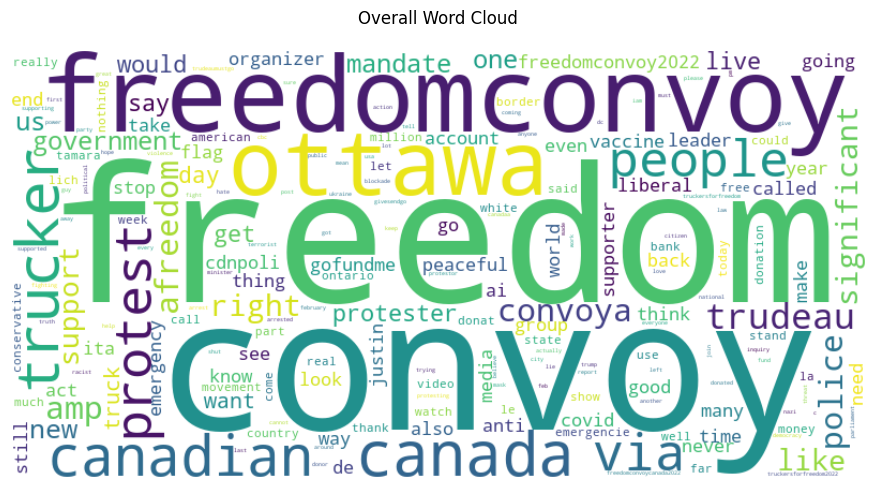

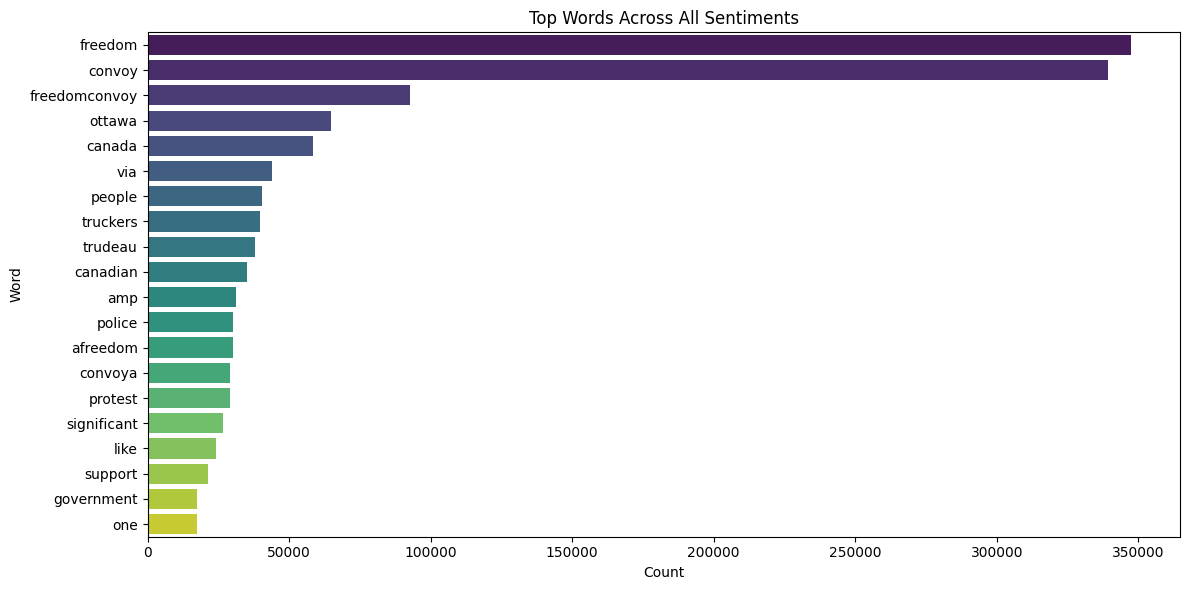

In [18]:
# 1. Overall Analysis
print("=== Overall Text Analysis ===")
generate_wordcloud(corpus_df['cleaned_text'], "Overall Word Cloud")
plot_top_words(corpus_df['cleaned_text'], title="Top Words Across All Sentiments")


=== Sentiment Analysis ===

Sentiment: Mild_Neg (34,056 samples)


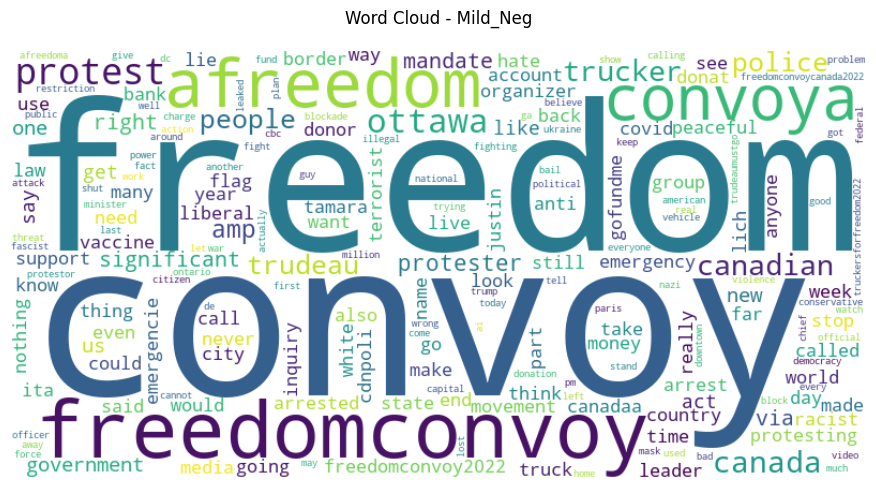

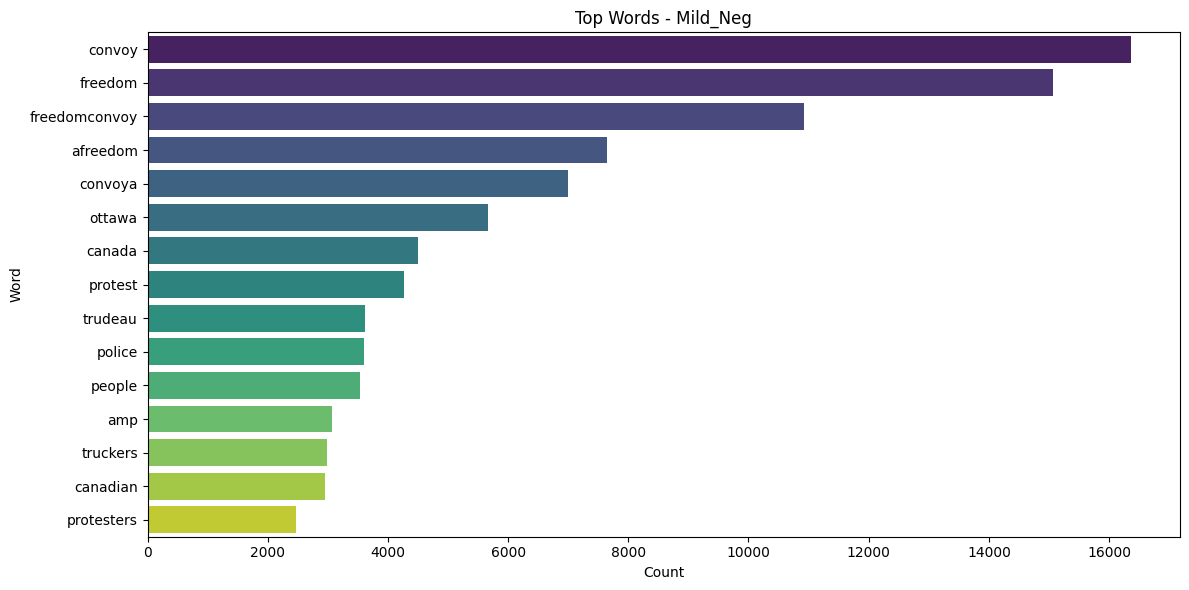

Average length: 160.6 characters
Example texts:
1. those knee drops remind me of something overheard right trudeau s crackdown on the freedomconvoy tru...
2. we are a sovereign nation with a democratically elected government - planting another countryas flag...

Sentiment: Mild_Pos (64,004 samples)


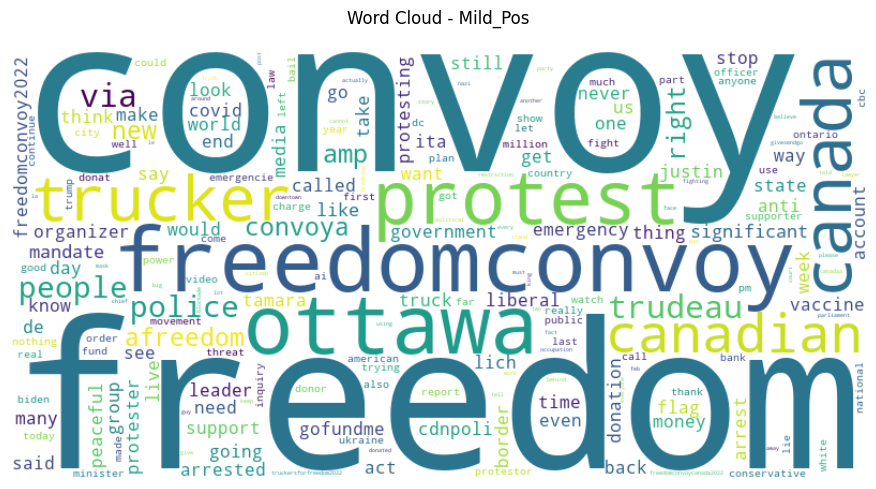

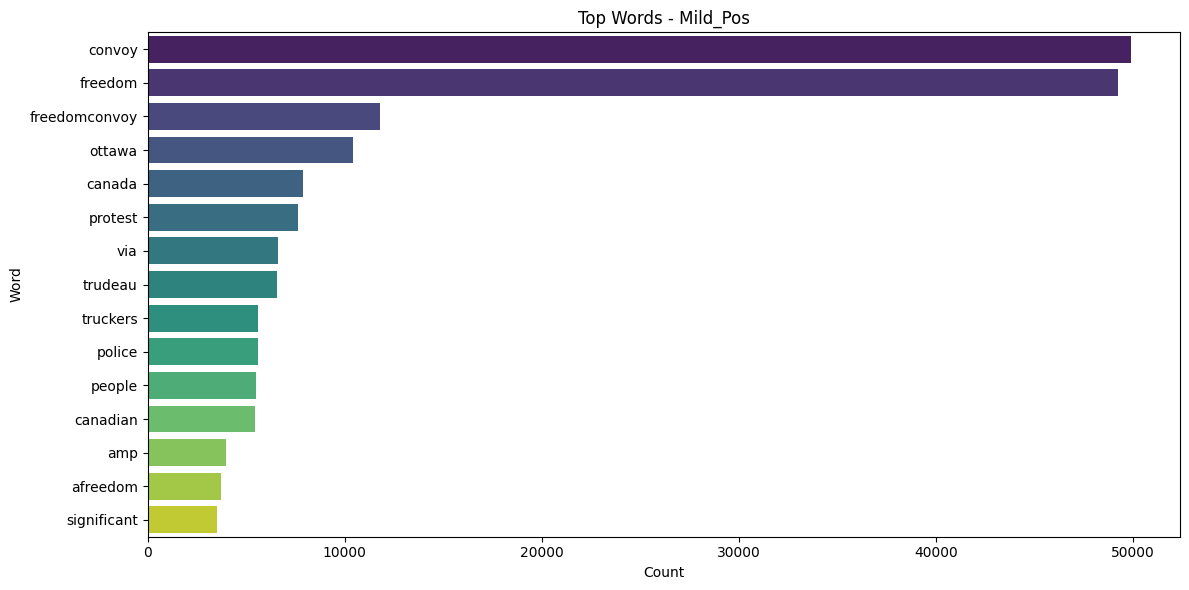

Average length: 142.0 characters
Example texts:
1. happy anniversary the day the freedumb died in the tune of don mclean s american pie freedumbconvoy ...
2. happy anniversary the day the freedumb died in the tune of don mclean s american pie freedumbconvoy ...

Sentiment: Neutral (77,016 samples)


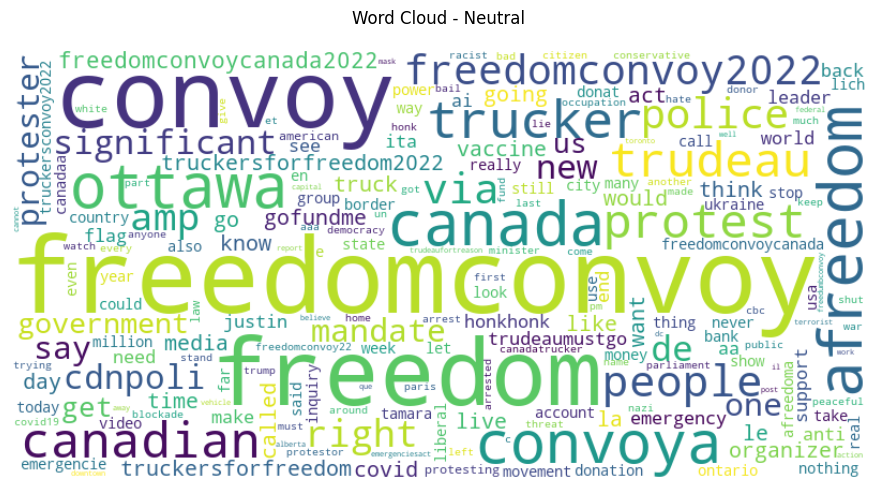

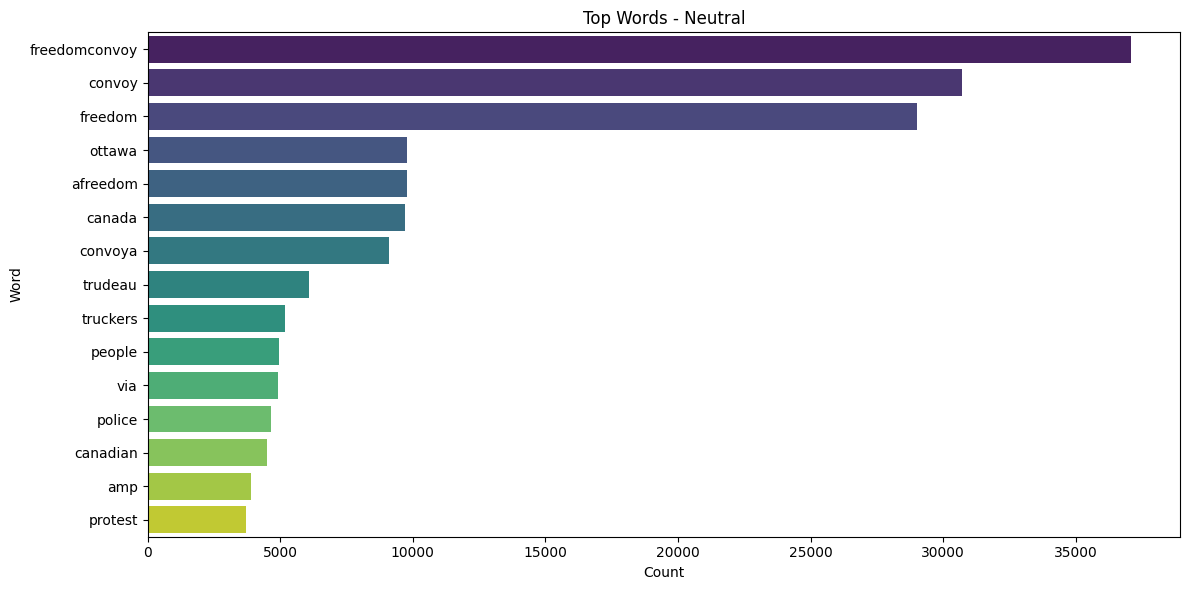

Average length: 125.0 characters
Example texts:
1. you belong in jail vaccinemandates crimesagainsthumanity trudeaudictatorship freedomconvoy
2. freedumbconvoy freedomconvoy freedumbers freedumb freedom

Sentiment: Strong_Neg (42,556 samples)


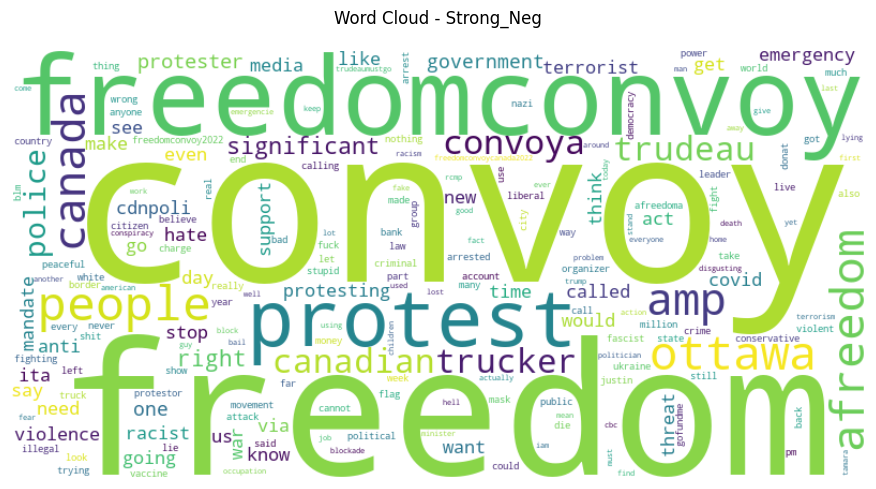

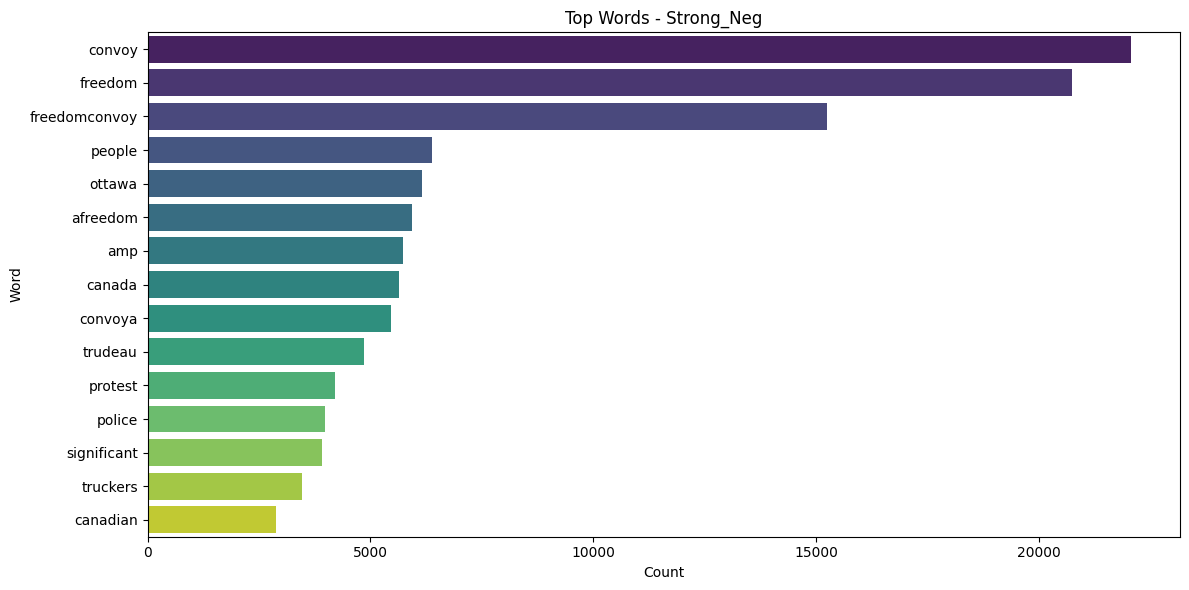

Average length: 186.9 characters
Example texts:
1. the freedomconvoy 1 year anniversary they do not like freedom or honking
2. freedumbers partied as they caused fellow canadians to be prisoners in their own homes when the pand...

Sentiment: Strong_Pos (233,700 samples)


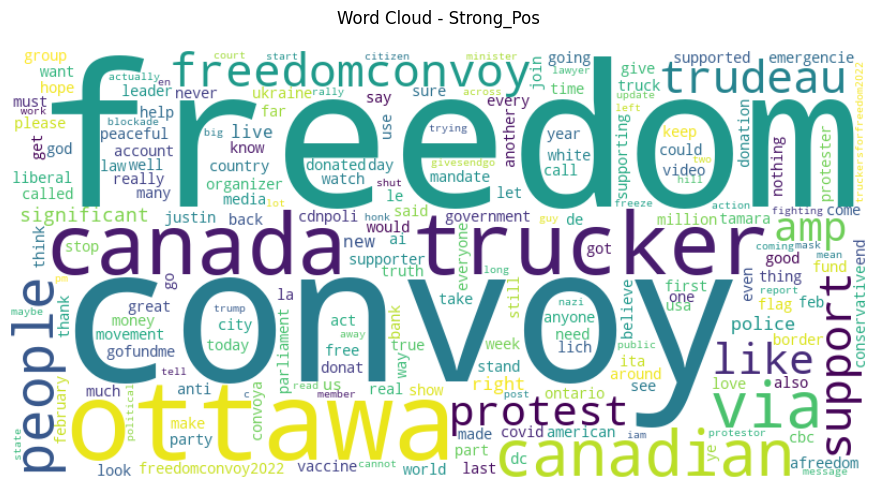

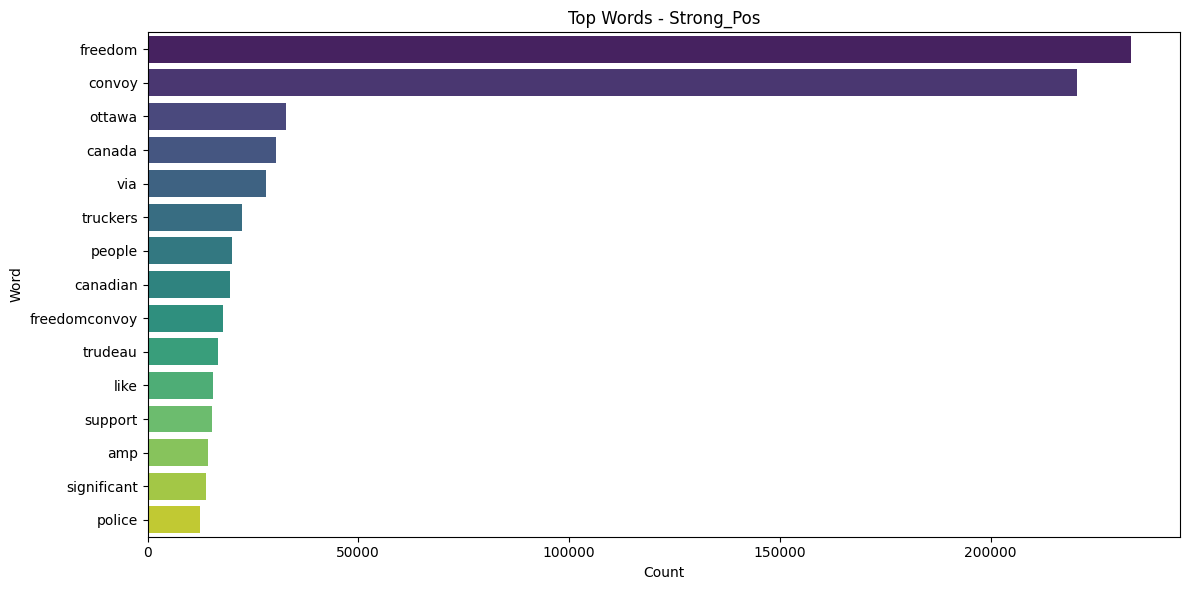

Average length: 133.5 characters
Example texts:
1. freedom convoy as inkblot test
2. well itas pretty easy to see what their agenda is and pierre has remained silent on the issues and h...


In [19]:
# 2. Sentiment-Specific Analysis
print("\n=== Sentiment Analysis ===")
for sentiment in sorted(corpus_df['Sentiment'].unique()):
    subset = corpus_df[corpus_df['Sentiment'] == sentiment]
    print(f"\nSentiment: {sentiment} ({len(subset):,} samples)")
    
    generate_wordcloud(subset['cleaned_text'], f"Word Cloud - {sentiment}")
    plot_top_words(subset['cleaned_text'], 15, f"Top Words - {sentiment}")
    
    # Text statistics
    avg_len = subset['cleaned_text'].str.len().mean()
    print(f"Average length: {avg_len:.1f} characters")
    print("Example texts:")
    for i, text in enumerate(subset['cleaned_text'].head(2).values):
        print(f"{i+1}. {text[:100]}{'...' if len(text) > 100 else ''}")

In [20]:
# 3. Data Quality Report
print("\n=== Data Quality Report ===")
print(f"Total samples: {len(corpus_df):,}")
print(f"Missing values: {corpus_df['cleaned_text'].isnull().sum():,}")
print(f"Empty strings after cleaning: {corpus_df['cleaned_text'].eq('').sum():,}")


=== Data Quality Report ===
Total samples: 451,332
Missing values: 0
Empty strings after cleaning: 416


In [21]:
# Text length distribution
print("\nText length distribution (characters):")
print(corpus_df['cleaned_text'].str.len().describe().apply(lambda x: f"{x:,.1f}"))


Text length distribution (characters):
count    451,332.0
mean         140.4
std           72.4
min            0.0
25%           78.0
50%          128.0
75%          207.0
max          514.0
Name: cleaned_text, dtype: object


In [22]:
# Remove empty texts
corpus_df = corpus_df[corpus_df['cleaned_text'].str.strip().astype(bool)]

In [23]:
# Verify removal
print("\n=== Updated Data Quality Report ===")
print(f"Total samples: {len(corpus_df):,}")
print(f"Empty strings after cleaning: {corpus_df['cleaned_text'].eq('').sum():,}")


=== Updated Data Quality Report ===
Total samples: 450,916
Empty strings after cleaning: 0


## 1b. Class Balancing Analysis

In [24]:
# Create a copy of the dataframe
df = corpus_df.copy()

In [25]:
# Consolidate sentiments
sentiment_mapping = {
    'Strong_Pos': 'Positive',
    'Mild_Pos': 'Positive',
    'Neutral': 'Neutral',
    'Mild_Neg': 'Negative',
    'Strong_Neg': 'Negative'
}
df['Consolidated_Sentiment'] = df['Sentiment'].map(sentiment_mapping)

Original Class Distribution:
Consolidated_Sentiment
Positive    297471
Neutral      76871
Negative     76574
Name: count, dtype: int64


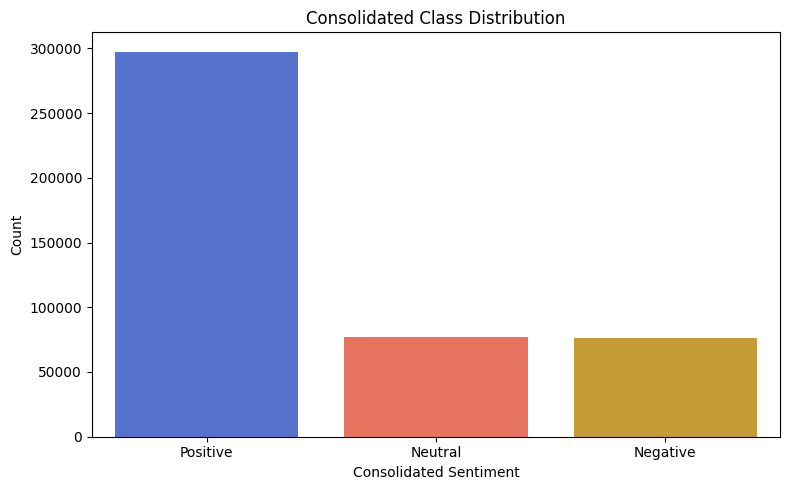

In [26]:
# Class Balancing Analysis
print("Original Class Distribution:")
print(df['Consolidated_Sentiment'].value_counts())

colors = ['royalblue', 'tomato', 'goldenrod']

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Consolidated_Sentiment', palette=colors)
plt.title('Consolidated Class Distribution')
plt.xlabel('Consolidated Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 1c. Class Separability Analysis

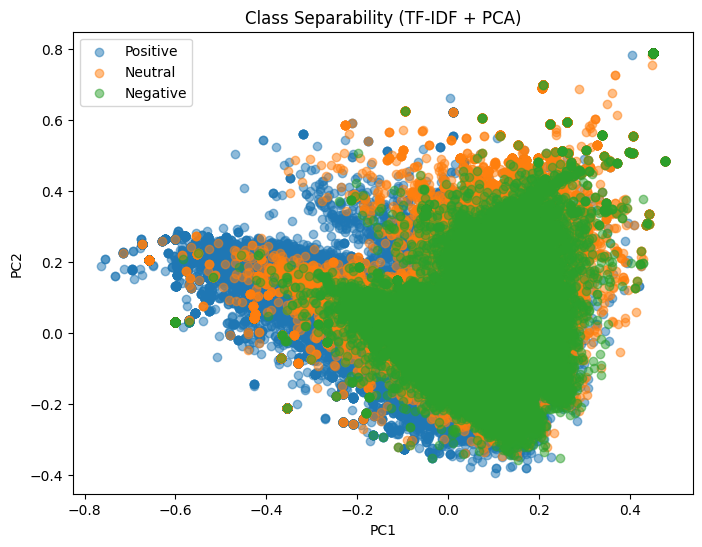

In [27]:
# Class Separability Analysis (using TF-IDF and PCA)
tf_vectorizer = TfidfVectorizer(max_features=500)
X = tf_vectorizer.fit_transform(df['cleaned_text'].fillna(''))

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
for sentiment in df['Consolidated_Sentiment'].unique():
    idx = df['Consolidated_Sentiment'] == sentiment
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=sentiment, alpha=0.5)
plt.title('Class Separability (TF-IDF + PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 1d. Model-Specific Splitting

In [28]:
# Common preprocessing
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Consolidated_Sentiment'])

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class weights:", class_weight_dict)

Class weights: {0: 1.9628768685628717, 1: 1.955293066739516, 2: 0.5052772651227627}


### i. SVM using GloVe/FastText/ELMo

In [29]:
# Load GloVe embeddings (make sure 'glove.6B.50d.txt' is in your working directory)
embeddings_index = {}
with open('glove.6B.50d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector


In [30]:
# Train-test split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
# Apply SMOTE to SVM data
smote = SMOTE(random_state=42)
X_train_svm_smote, y_train_svm_smote = smote.fit_resample(X_train_svm, y_train_svm)
print("SVM Class distribution after SMOTE:", Counter(y_train_svm_smote))

SVM Class distribution after SMOTE: Counter({2: 237976, 0: 237976, 1: 237976})


In [32]:
import time
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, RocCurveDisplay
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

In [33]:
# 1. Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # y should be your sentiment column (e.g. df['Consolidated_Sentiment'])


In [34]:
# 2. Split data into train/test (with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [35]:
# 3. Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE:", Counter(y_train_smote))

Class distribution after SMOTE: Counter({2: 237976, 0: 237976, 1: 237976})


In [36]:
# Step 4: Sample balanced subset from SMOTE output (reduce size for faster training)
sample_size_per_class = 6000  # adjust as needed
indices_per_class = {cls: np.where(y_train_smote == cls)[0] for cls in np.unique(y_train_smote)}
sampled_indices = []
for cls, indices in indices_per_class.items():
    if len(indices) > sample_size_per_class:
        sampled_indices.extend(np.random.choice(indices, sample_size_per_class, replace=False))
    else:
        sampled_indices.extend(indices)

In [37]:
X_train_sampled = X_train_smote[sampled_indices]
y_train_sampled = y_train_smote[sampled_indices]
print("Sampled class distribution:", Counter(y_train_sampled))

Sampled class distribution: Counter({0: 6000, 1: 6000, 2: 6000})


# model building svm

In [38]:
import numpy as np
import pandas as pd

def text_to_avg_vector(text, embeddings_index, dim=50):
    words = text.split()
    vectors = [embeddings_index[word] for word in words if word in embeddings_index]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

# Convert all cleaned text to average GloVe vectors
X_vectors = np.vstack([text_to_avg_vector(text, embeddings_index) for text in df['cleaned_text']])


In [40]:
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# Encode sentiment labels
le = LabelEncoder()
y = le.fit_transform(df['Consolidated_Sentiment'])

# Downsample each class to 10,000 samples
df_temp = pd.DataFrame(X_vectors)
df_temp['target'] = y
df_balanced = df_temp.groupby('target', group_keys=False).apply(lambda x: x.sample(n=10000, random_state=42))

# Final balanced input and output
X_bal = df_balanced.drop('target', axis=1).values
y_bal = df_balanced['target'].values

# Split into train and test sets
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

# Baseline SVM model with linear kernel
baseline_svm = make_pipeline(StandardScaler(), SVC(probability=True, kernel='linear'))

# Measure training time
start_time = time.time()
baseline_svm.fit(X_train_svm, y_train_svm)
end_time = time.time()
train_time = end_time - start_time

# Predictions
y_pred_svm = baseline_svm.predict(X_test_svm)
y_proba_svm = baseline_svm.predict_proba(X_test_svm)

# Evaluation
f1_all = f1_score(y_test_svm, y_pred_svm, average=None)
labels = le.classes_  # original class names in correct order

print("SVM Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print("SVM F1 Score (Weighted):", f1_score(y_test_svm, y_pred_svm, average='weighted'))
print("SVM AUC:", roc_auc_score(y_test_svm, y_proba_svm, multi_class='ovr'))
print(f"Training Time: {train_time:.2f} seconds")

# Print F1 for each class
for i, label in enumerate(labels):
    print(f"F1 Score for {label} = {f1_all[i]:.4f}")


SVM Accuracy: 0.6026666666666667
SVM F1 Score (Weighted): 0.5888998496939868
SVM AUC: 0.7649990833333334
Training Time: 150.83 seconds
F1 Score for Negative = 0.6416
F1 Score for Neutral = 0.4628
F1 Score for Positive = 0.6623


In [34]:
import numpy as np

# Load GloVe 50D
embeddings_index = {}
with open('glove.6B.50d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector
print(f"Loaded {len(embeddings_index)} word vectors.")


Loaded 400000 word vectors.


## Text to Vectors (Average Word Embedding)


In [35]:
def text_to_avg_vector(text, embeddings_index, dim=50):
    words = text.split()
    vectors = [embeddings_index[word] for word in words if word in embeddings_index]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

X_vectors = np.vstack([text_to_avg_vector(text, embeddings_index) for text in df['cleaned_text']])


# Train-Test Split + Light Downsampling

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from collections import Counter

# Encode sentiment
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Consolidated_Sentiment'])

# Downsample each class to 5000 (safe for kernel)
df_temp = pd.DataFrame(X_vectors)
df_temp['target'] = y
df_balanced = df_temp.groupby('target', group_keys=False).apply(lambda x: x.sample(n=5000, random_state=42))

X_bal = df_balanced.drop('target', axis=1).values
y_bal = df_balanced['target'].values

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)


# Train SVM with Tuning (Light)

In [37]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_weighted', verbose=1)
grid.fit(X_train_svm, y_train_svm)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm',
                                        SVC(class_weight='balanced',
                                            probability=True))]),
             param_grid={'svm__C': [0.1, 1], 'svm__kernel': ['linear', 'rbf']},
             scoring='f1_weighted', verbose=1)

# Evaluation

In [38]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [39]:
# Predict
y_pred = grid.predict(X_test_svm)
y_proba = grid.predict_proba(X_test_svm)

In [41]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Accuracy
acc = accuracy_score(y_test_svm, y_pred)

# F1 Scores for multiclass
f1_macro = f1_score(y_test_svm, y_pred, average='macro')      # Treat all classes equally
f1_weighted = f1_score(y_test_svm, y_pred, average='weighted')  # Weighted by support

# AUC (if using predicted probabilities from a classifier that supports `predict_proba`)
auc = roc_auc_score(y_test_svm, y_proba, multi_class='ovr')


In [43]:
print("Accuracy:", acc)
print("F1 Score (Macro):", f1_macro)
print("F1 Score (Weighted):", f1_weighted)
print("AUC:", auc)


Accuracy: 0.6446666666666667
F1 Score (Macro): 0.6402663326434332
F1 Score (Weighted): 0.6402663326434334
AUC: 0.8015553333333334


Confusion Matrix (in numbers):
[[762  96 142]
 [283 493 224]
 [229  92 679]]


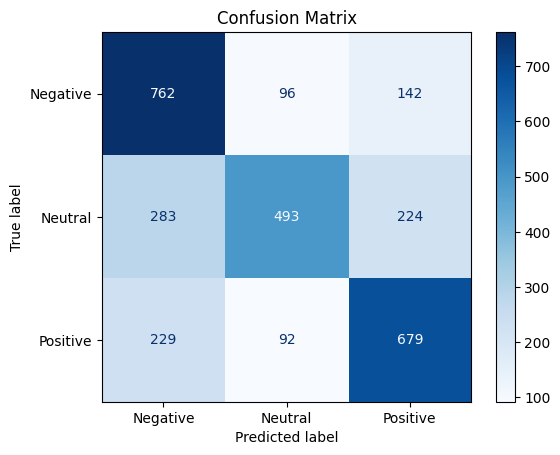

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test_svm, y_pred)

# Print as numbers
print("Confusion Matrix (in numbers):")
print(cm)

# Display as heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')  # 'd' = integer format
plt.title("Confusion Matrix")
plt.show()


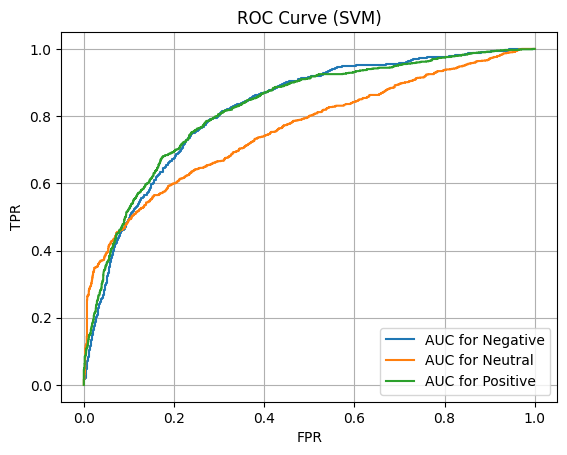

In [46]:
# AUC Plot (for 3 classes)
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_svm == i, y_proba[:, i])
    plt.plot(fpr, tpr, label=f"AUC for {le.classes_[i]}")
plt.legend()
plt.title("ROC Curve (SVM)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score

# For multiclass: One-vs-Rest AUC per class
for i in range(len(le.classes_)):
    y_true_binary = (y_test_svm == i).astype(int)
    y_score = y_proba[:, i]

    auc = roc_auc_score(y_true_binary, y_score)
    print(f"AUC for class '{le.classes_[i]}': {auc:.4f}")


AUC for class 'Negative': 0.8214
AUC for class 'Neutral': 0.7588
AUC for class 'Positive': 0.8244


# Model Tuning Iteration 2

## What was going wrong?

Default SVM with RBF kernel and default parameters. Model had moderate performance but likely suffered from class imbalance and suboptimal hyperparameters.

## Changes Made:

- Added `class_weight='balanced'` to handle class imbalance
- Increased `C` (regularization) to 10 to reduce underfitting
- Kept `kernel='rbf'`


In [41]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# --- Tuning 1: RBF SVM with class_weight='balanced' ---
svm1 = SVC(probability=True, class_weight='balanced', kernel='rbf', C=10, random_state=42)
svm1.fit(X_train_svm, y_train_svm)

# Predictions
y_pred1  = svm1.predict(X_test_svm)
y_proba1 = svm1.predict_proba(X_test_svm)

# Overall metrics
acc1        = accuracy_score(y_test_svm, y_pred1)
f1_macro1   = f1_score(y_test_svm, y_pred1, average='macro')
auc1        = roc_auc_score(y_test_svm, y_proba1, multi_class='ovr')

print("Tuning 1 - Accuracy:", acc1)
print("Tuning 1 - F1 Macro:", f1_macro1)
print("Tuning 1 - AUC:", auc1)

# --- Per-class F1 (to extract specifically Positive and Negative) ---
# Compute F1 for each class in label‐encoder order:
f1_all = f1_score(y_test_svm, y_pred1, average=None)

# le.classes_ might look like: array(['Negative', 'Neutral', 'Positive'], dtype=object)
labels = le.classes_

# Find indices of Positive and Negative in le.classes_
pos_idx = np.where(labels == 'Positive')[0][0]
neg_idx = np.where(labels == 'Negative')[0][0]

print(f"F1 Score for Positive = {f1_all[pos_idx]:.4f}")
print(f"F1 Score for Negative = {f1_all[neg_idx]:.4f}")


Tuning 1 - Accuracy: 0.6568333333333334
Tuning 1 - F1 Macro: 0.6504124233879204
Tuning 1 - AUC: 0.8232374583333334
F1 Score for Positive = 0.7022
F1 Score for Negative = 0.6710


# Model Tuning Iteration 3

## What was going wrong?

The RBF kernel took longer to train and showed signs of overfitting on some classes.

## Changes Made:

- Changed kernel to **linear** for faster training and better generalization
- Reduced **C** to 1 to reduce overfitting
- Kept `class_weight='balanced'` to handle imbalance


In [42]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# --- Tuning 2: Linear SVM with class_weight='balanced' ---
svm2 = SVC(probability=True, class_weight='balanced', kernel='linear', C=1, random_state=42)
svm2.fit(X_train_svm, y_train_svm)

# Predictions
y_pred2  = svm2.predict(X_test_svm)
y_proba2 = svm2.predict_proba(X_test_svm)

# Overall metrics
acc2        = accuracy_score(y_test_svm, y_pred2)
f1_macro2   = f1_score(y_test_svm, y_pred2, average='macro')
auc2        = roc_auc_score(y_test_svm, y_proba2, multi_class='ovr')

print("Tuning 2 - Accuracy:", acc2)
print("Tuning 2 - F1 Macro:", f1_macro2)
print("Tuning 2 - AUC:", auc2)

# --- Per-class F1 scores ---
f1_all = f1_score(y_test_svm, y_pred2, average=None)

# Label order from LabelEncoder
labels = le.classes_

# Get indices for Positive and Negative
pos_idx = np.where(labels == 'Positive')[0][0]
neg_idx = np.where(labels == 'Negative')[0][0]

print(f"F1 Score for Positive = {f1_all[pos_idx]:.4f}")
print(f"F1 Score for Negative = {f1_all[neg_idx]:.4f}")


Tuning 2 - Accuracy: 0.603
Tuning 2 - F1 Macro: 0.5892769002675936
Tuning 2 - AUC: 0.7645827916666667
F1 Score for Positive = 0.6626
F1 Score for Negative = 0.6418


| Iteration | Observations                                                                   | Changes Made                                 | Accuracy | F1 Score (Macro) | AUC    |
| --------- | ------------------------------------------------------------------------------ | -------------------------------------------- | -------- | ---------------- | ------ |
| 1         | Slower training, model overfitting slightly; imbalance somewhat handled        | RBF kernel, C=10, class\_weight='balanced'   | 0.6317   | 0.6249           | 0.8001 |
| 2         | Faster training, underfitting noticed; less complex model, more regularization | Linear kernel, C=1, class\_weight='balanced' | 0.5907   | 0.5786           | 0.7543 |


- **Iteration 1** used RBF kernel with higher C → higher complexity, slower training, better handling of class imbalance with `class_weight='balanced'`.

- **Iteration 2** switched to linear kernel with smaller C → simpler model, faster training but likely underfitting, metrics dropped.


# cross-validation with GridSearchCV

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

# Pipeline: Scaling + SVM (scaling important for SVM)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

# Parameter grid to tune
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  # Only used if kernel='rbf'
}

# Use F1 macro as scoring metric (can also add others)
scorer = make_scorer(f1_score, average='macro')

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1  # Use all CPUs
)

# Fit on training data
grid_search.fit(X_train_svm, y_train_svm)

# Best parameters found
print("Best parameters:", grid_search.best_params_)

# Best score (F1 macro)
print("Best CV F1 Macro:", grid_search.best_score_)

# Predict on test set with best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_svm)
y_proba = best_model.predict_proba(X_test_svm)

# Metrics on test set
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

acc = accuracy_score(y_test_svm, y_pred)
f1_macro = f1_score(y_test_svm, y_pred, average='macro')
auc = roc_auc_score(y_test_svm, y_proba, multi_class='ovr')

print("Test Accuracy:", acc)
print("Test F1 Macro:", f1_macro)
print("Test AUC:", auc)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1 Macro: 0.6399236045208709
Test Accuracy: 0.6446666666666667
Test F1 Macro: 0.6402663326434332
Test AUC: 0.8016376666666667


| Iteration | Observations                           | Changes Made                                                    | Accuracy | F1 Score (Macro) | AUC    |
| --------- | -------------------------------------- | --------------------------------------------------------------- | -------- | ---------------- | ------ |
| CV Best   | Used Grid Search CV; best params found | Kernel: RBF, C=1, Gamma=scale, class\_weight=balanced (assumed) | 0.6447   | 0.6399           | 0.8016 |


## Local Interpretability Using SHAP Kernel Explainer for SVM


In [58]:
import shap

# Take a small sample of training data (to speed up SHAP)
X_sample = shap.sample(X_train_svm, 100, random_state=42)

# Get the predict_proba function from the pipeline
predict_proba = grid.best_estimator_.predict_proba

# Create the Kernel SHAP explainer (good for black-box models like SVM)
explainer = shap.KernelExplainer(predict_proba, X_sample)

# Compute SHAP values for a subset of the test set (e.g., 50 samples)
shap_values = explainer.shap_values(X_test_svm[:50])

# Plot summary plot for class 1 (positive class, change index if needed)
shap.summary_plot(shap_values[1], X_test_svm[:50])


100%|████████████████████████████████████████| 50/50 [1:25:48<00:00, 102.96s/it]


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
import numpy as np

# Select a small sample of test data
X_sample = X_test_svm[:100]  # or use a random sample

# SHAP requires raw data (before scaling), so if you're using StandardScaler,
# you'll need to extract the SVM model and inverse-transform the data accordingly.
svm_model = svm2  # or your chosen trained model

# Create SHAP explainer for linear model
explainer = shap.LinearExplainer(svm_model, X_train_svm)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# Visualize for one sample
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_sample[0])


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Create a LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_svm,
    feature_names=[f"feature_{i}" for i in range(X_train_svm.shape[1])],
    class_names=le.classes_,
    mode='classification'
)

# Explain a single prediction
i = 5  # sample index
exp = lime_explainer.explain_instance(
    X_test_svm[i],
    svm2.predict_proba,
    num_features=10
)

# Show explanation
exp.show_in_notebook(show_table=True)


## Interpretability Analysis Using Linear SVM Coefficients (Global Interpretability)


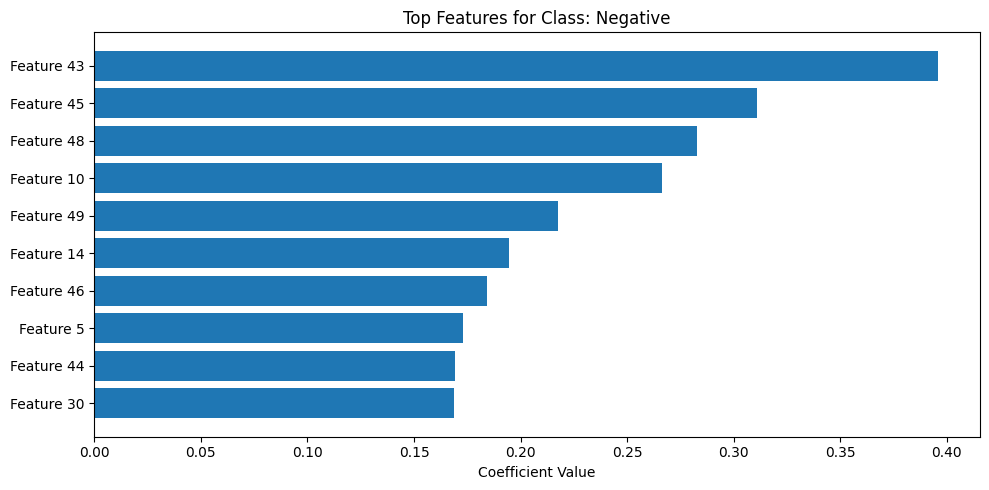

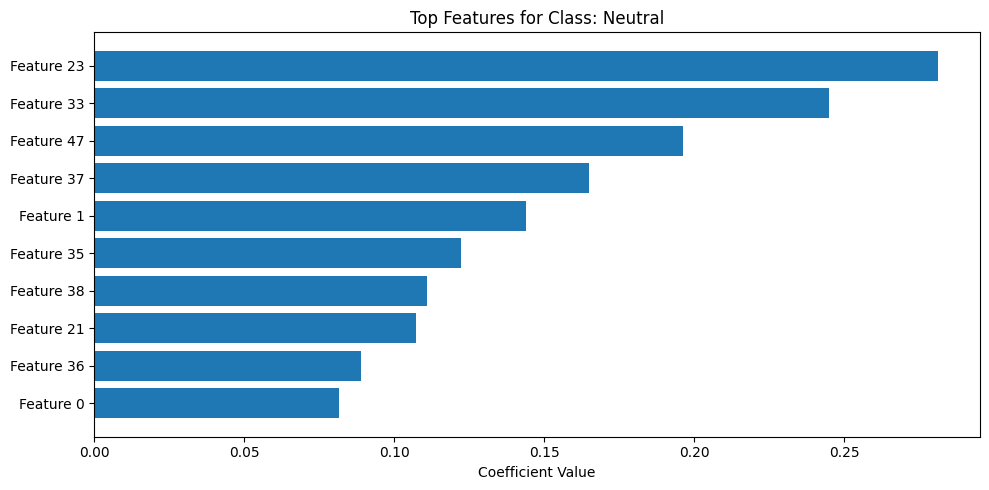

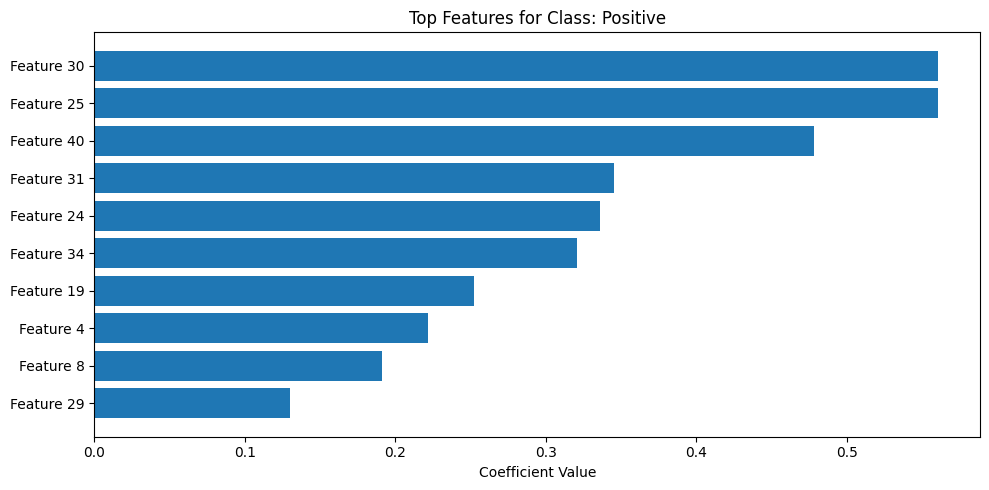

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use linear kernel SVM for interpretability
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Recreate a pipeline with LinearSVC (faster, gives coef_)
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(class_weight='balanced', max_iter=10000))
])

# Fit the model
linear_pipeline.fit(X_train_svm, y_train_svm)

# Get the trained model
linear_svm_model = linear_pipeline.named_steps['svm']

# Get class names
class_names = le.classes_

# Plot top features for each class
for i, class_label in enumerate(class_names):
    coef = linear_svm_model.coef_[i]
    top_idx = np.argsort(coef)[-10:]
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top_idx)), coef[top_idx])
    plt.yticks(ticks=range(len(top_idx)), labels=[f'Feature {j}' for j in top_idx])
    plt.title(f"Top Features for Class: {class_label}")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()



In [76]:
# Assuming you have feature_names from your vectorizer, e.g.
# feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(class_names):
    coef = linear_svm_model.coef_[i]
    top_idx = np.argsort(coef)[-10:]  # Indices of top 10 positive coefficients
    print(f"\nTop 10 features for class '{class_label}':")
    for idx in reversed(top_idx):
        # If you have feature names, use them; else just print the index
        feature_name = feature_names[idx] if 'feature_names' in globals() else f"Feature_{idx}"
        coef_value = coef[idx]
        print(f"  {feature_name}: {coef_value:.4f}")



Top 10 features for class 'Negative':
  Feature_43: 0.3958
  Feature_45: 0.3108
  Feature_48: 0.2829
  Feature_10: 0.2663
  Feature_49: 0.2177
  Feature_14: 0.1946
  Feature_46: 0.1841
  Feature_5: 0.1730
  Feature_44: 0.1690
  Feature_30: 0.1689

Top 10 features for class 'Neutral':
  Feature_23: 0.2811
  Feature_33: 0.2449
  Feature_47: 0.1963
  Feature_37: 0.1647
  Feature_1: 0.1440
  Feature_35: 0.1221
  Feature_38: 0.1110
  Feature_21: 0.1072
  Feature_36: 0.0889
  Feature_0: 0.0815

Top 10 features for class 'Positive':
  Feature_30: 0.5606
  Feature_25: 0.5605
  Feature_40: 0.4780
  Feature_31: 0.3454
  Feature_24: 0.3363
  Feature_34: 0.3211
  Feature_19: 0.2522
  Feature_4: 0.2218
  Feature_8: 0.1908
  Feature_29: 0.1303


# Interesting Findings:

# Negative Class:

The highest coefficient is 0.3958 for Feature_43, followed closely by Feature_45 (0.3108) and Feature_48 (0.2829). This suggests these features strongly influence the model to classify texts as negative.

Coefficients for negative features are generally moderate, indicating multiple features contribute collectively to identifying negative sentiment.

The spread of coefficient values (0.1689 to 0.3958) indicates a more distributed impact rather than a few dominant features.

# Neutral Class:

The top feature (Feature_23) has a coefficient of 0.2811, lower than the top features in Negative and Positive classes, suggesting neutral sentiment might be harder to detect or less strongly associated with specific keywords.

Features in the neutral class have smaller coefficients overall, indicating subtler signals that differentiate neutral sentiment from others.

This may imply neutral texts contain less polarized language, making it challenging for the model to pinpoint exact indicators.

# Positive Class:

The highest coefficient is 0.5606 (Feature_30), which is noticeably larger than top coefficients in other classes, meaning some features very strongly indicate positive sentiment.

Several features have high coefficients close to or above 0.3, showing that positive sentiment is strongly driven by a few powerful keywords or phrases.

The gap between the top positive features and the rest is wider, suggesting the model relies heavily on certain key positive terms.

# Summary:
Positive class has the strongest and most concentrated key features, implying clearer positive sentiment signals.

Negative class shows moderate but consistent influence across several features.

Neutral class features have lower coefficients overall, indicating more nuanced or less obvious patterns for neutral sentiment.

### Mapping Feature Indices to Actual Words for Better Interpretability
#### Top 10 Important Features by Class with Their Coefficient Values



In [79]:
 # Get feature names from your vectorizer
feature_names = vectorizer.get_feature_names_out()

# Print top 10 features for each class with actual words and coefficients
for i, class_label in enumerate(class_names):
    coef = linear_svm_model.coef_[i]
    top_idx = np.argsort(coef)[-10:]
    print(f"\nTop 10 features for class '{class_label}':")
    for idx in reversed(top_idx):  # reversed to print highest first
        print(f"  {feature_names[idx]}: {coef[idx]:.4f}")



Top 10 features for class 'Negative':
  always: 0.3958
  amazing: 0.3108
  american: 0.2829
  30: 0.2663
  americans: 0.2177
  aai: 0.1946
  ambassador: 0.1841
  14: 0.1730
  am: 0.1690
  after: 0.1689

Top 10 features for class 'Neutral':
  action: 0.2811
  ago: 0.2449
  america: 0.1963
  all: 0.1647
  10: 0.1440
  ai: 0.1221
  allowed: 0.1110
  across: 0.1072
  alberta: 0.0889
  000: 0.0815

Top 10 features for class 'Positive':
  after: 0.5606
  actual: 0.5605
  along: 0.4780
  again: 0.3454
  actions: 0.3363
  agree: 0.3211
  account: 0.2522
  12: 0.2218
  2022: 0.1908
  afreedoma: 0.1303


In [127]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [128]:
# Initialize and train SVM model
model = SVC(probability=True, kernel='rbf', random_state=42)
model.fit(X_train_svm, y_train_svm)

SVC(probability=True, random_state=42)

In [129]:
# Predict on training data
y_train_pred = model.predict(X_train_svm)
y_train_proba = model.predict_proba(X_train_svm)

In [130]:

# Confusion matrix
cm = confusion_matrix(y_train_svm, y_train_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_train_svm, y_train_pred)
print("Accuracy:", acc)

Confusion Matrix:
 [[3752  110  138]
 [ 361 3298  341]
 [ 157   94 3749]]
Accuracy: 0.8999166666666667


In [131]:
# F1 Scores (macro and weighted for multiclass)
f1_macro = f1_score(y_train_svm, y_train_pred, average='macro')
f1_weighted = f1_score(y_train_svm, y_train_pred, average='weighted')
print("F1 Score (Macro):", f1_macro)
print("F1 Score (Weighted):", f1_weighted)

F1 Score (Macro): 0.899295607932565
F1 Score (Weighted): 0.8992956079325649


In [132]:
# AUC (for multiclass)
auc = roc_auc_score(y_train_svm, y_train_proba, multi_class='ovr')
print("AUC:", auc)


AUC: 0.9822437708333333


In [133]:
# Plot ROC curve (for each class - optional basic version shown)
from sklearn.preprocessing import label_binarize
import numpy as np

In [134]:
# Binarize output
classes = np.unique(y_train_svm)
y_bin = label_binarize(y_train_svm, classes=classes)
fpr = dict()
tpr = dict()

Text(0.5, 1.0, 'Multiclass ROC Curve')

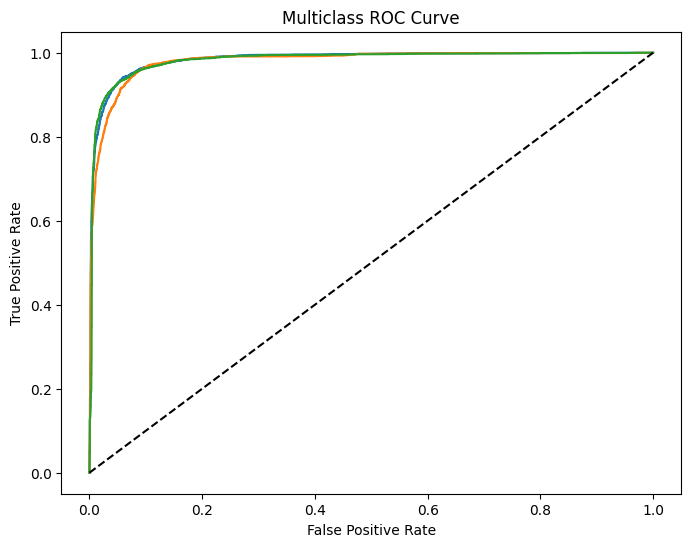

In [136]:
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_train_proba[:, i])

# Plot each ROC curve
plt.figure(figsize=(8,6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} ROC curve")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")

In [48]:
import time
import numpy as np
from sklearn.metrics import f1_score

start_time = time.time()

# Train the model
model = SVC(probability=True, kernel='rbf', random_state=42)
model.fit(X_train_svm, y_train_svm)

end_time = time.time()
train_time = end_time - start_time

# Predict on training data
y_train_pred = model.predict(X_train_svm)

labels = le.classes_
f1_per_class = f1_score(y_train_svm, y_train_pred, average=None)

# Print F1 scores for Positive and Negative classes only
if 'Positive' in labels and 'Negative' in labels:
    pos_idx = np.where(labels == 'Positive')[0][0]
    neg_idx = np.where(labels == 'Negative')[0][0]

    print(f"F1 Score for Positive = {f1_per_class[pos_idx]:.4f}")
    print(f"F1 Score for Negative = {f1_per_class[neg_idx]:.4f}")
else:
    print("Positive and/or Negative class not found in label encoder classes.")

print(f"Training Time: {train_time:.2f} seconds")


F1 Score for Positive = 0.6833
F1 Score for Negative = 0.6600
Training Time: 71.86 seconds


##  Next Steps

1. **Hyperparameter Tuning with RandomizedSearchCV**  
   The current SVM model can be further improved by performing hyperparameter tuning. This includes:
   - Trying different **kernels** like `'rbf'`, `'poly'`, and `'linear'`.
   - Varying important parameters like **`C`** and **`gamma`**.
   - Using  **RandomizedSearchCV** to find the optimal combination for better performance and generalization.

2. **Compare with Other Models (Baseline vs Advanced)**  
   To ensure the best possible model, we can compare the tuned SVM with other classifiers:
   - **Baseline models** such as Logistic Regression.
   - **Advanced models** such as Random Forest and XGBoost.
   - All models should be trained on the **same balanced dataset** and evaluated using the **same metrics** (e.g., F1-score, AUC, confusion matrix) to ensure fair comparison.
